## Email assistant workflow

This agentic workflow can carry out various tasks related to email management, including sending emails, searching for emails from a specific sender, and deleting emails.

![Multiple tools.png](<attachment:Multiple tools.png>)
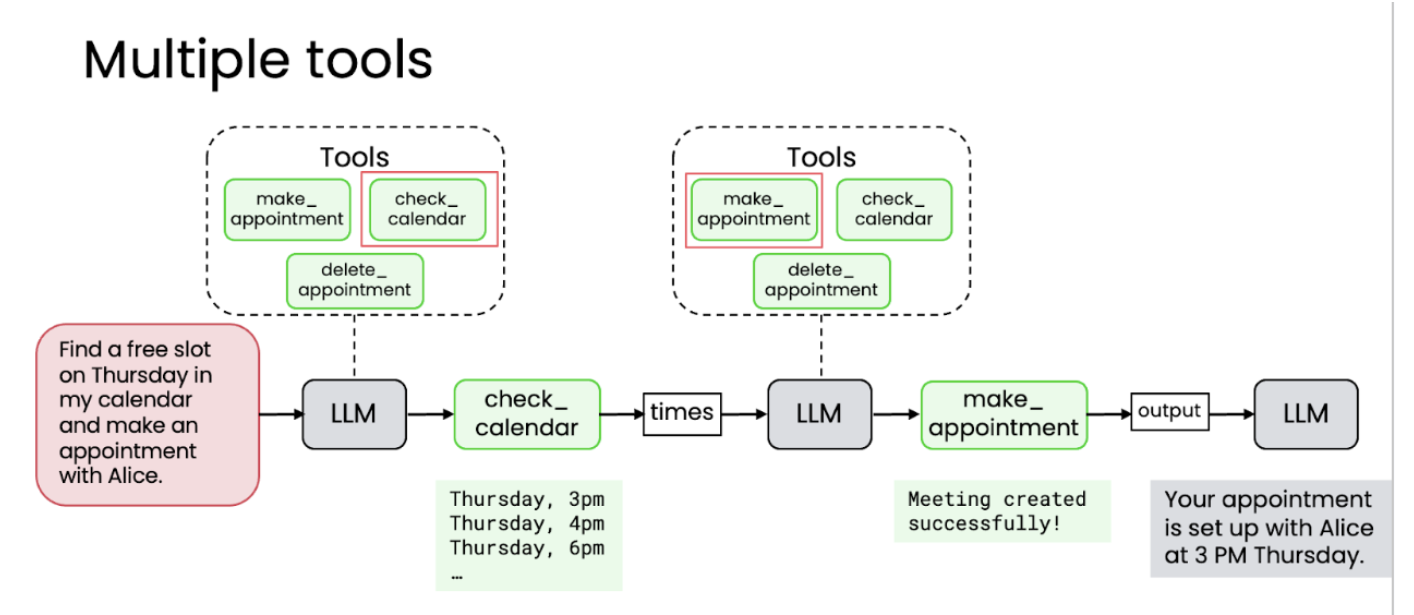

In [ ]:
from dotenv import load_dotenv
import aisuite as ai
import jsontool_choice=

import utils
import display_functions
import email_tools

load_dotenv()          
client = ai.Client()   

### Tool layer for the email agent

Take all the email endpoints which are working and expose them to the LLM as Python functions called **tools**. Each tool wraps a REST route, transforming raw API calls into actions the agent can perform—like list, read, search, send, delete, or toggle read.

In [ ]:
# Expose all the email tolls
# Test sending a new email and fetch it by ID
new_email = email_tools.send_email("test@example.com", "Lunch plans", "Shall we meet at noon?")
content_ = email_tools.get_email(new_email['id'])

# Uncomment the ones you want to try:
#content_ = email_tools.list_all_emails()
#content_ = email_tools.list_unread_emails()
#content_ = email_tools.search_emails("lunch")
#content_ = email_tools.filter_emails(recipient="test@example.com")
#content_ = email_tools.mark_email_as_read(new_email['id'])
#content_ = email_tools.mark_email_as_unread(new_email['id'])
#content_ = email_tools.search_unread_from_sender("test@example.com")
#content_ = email_tools.delete_email(new_email['id'])

utils.print_html(content=json.dumps(content_, indent=2), title="Testing the email_tools")

In [ ]:
def build_prompt(request_: str) -> str:
    return f"""
- You are an AI assistant specialized in managing emails.
- You can perform various actions such as listing, searching, filtering, and manipulating emails.
- Use the provided tools to interact with the email system.
- Never ask the user for confirmation before performing an action.
- If needed, my email address is "you@email.com" so you can use it to send emails or perform actions related to my account.

{request_.strip()}
"""

### LLM + Email tools

In [ ]:
# Try your own requests
prompt_ = build_prompt("Check for unread emails from boss@email.com, mark them as read, and send a polite follow-up.")

response = client.chat.completions.create(
    model="openai:gpt-4.1", # LLM
    messages=[{"role": "user", "content": (
        prompt_
    )}],
    tools=[ # list of tools that the LLM can access
        email_tools.search_unread_from_sender,
        email_tools.list_unread_emails,
        email_tools.search_emails,
        email_tools.get_email,
        email_tools.mark_email_as_read,
        email_tools.send_email
    ],
    max_turns=5,
)

display_functions.pretty_print_chat_completion(response)